# **Carga de librerías**

In [1]:
# Instalación de las librerías
%pip install torch torchvision scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 558.4 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 816.7 kB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 1.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.1 MB/s eta 0:00:0000:01m00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 5.9 MB/s eta 0:00:0000:01m0:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 7.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.5 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 7.4 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 5.0 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 9.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━

In [2]:
import torch
import torch.nn as nn # Modulo para redes neuronales
import torch.optim as optim # Modulo para optimizadores

# Modulo para cargar y transformar datos
import torchvision
from torchvision import datasets, transforms, models

# Modulo para visualización
import matplotlib.pyplot as plt
import numpy as np

# Modulo para evaluación de modelos
from sklearn.metrics import classification_report, confusion_matrix

import os

# **Carga del dataset**

In [7]:
raiz = '../data/Ojos'

# Datos de entrenamiento
train_dir = os.path.join(raiz, 'train')
train_dir_normal = os.path.join(train_dir, 'Normales')
train_dir_glaucoma = os.path.join(train_dir, 'Glaucomas')

# Datos de validación
val_dir = os.path.join(raiz, 'val')
val_dir_normal = os.path.join(val_dir, 'Normales')
val_dir_glaucoma = os.path.join(val_dir, 'Glaucomas')

# Datos de prueba
test_dir = os.path.join(raiz, 'test')
test_dir_normal = os.path.join(test_dir, 'Normales')
test_dir_glaucoma = os.path.join(test_dir, 'Glaucomas')

# Muestro la cantidad de imágenes en cada conjunto
suma_entrenamiento = len(os.listdir(train_dir_normal)) + len(os.listdir(train_dir_glaucoma))
suma_validacion = len(os.listdir(val_dir_normal)) + len(os.listdir(val_dir_glaucoma))
suma_prueba = len(os.listdir(test_dir_normal)) + len(os.listdir(test_dir_glaucoma))

print("Datos de entrenamiento:", suma_entrenamiento, "--- Normales:", len(os.listdir(train_dir_normal)), "--- Glaucoma:", len(os.listdir(train_dir_glaucoma)))
print("Datos de validación:", suma_validacion, "--- Normales:", len(os.listdir(val_dir_normal)), "--- Glaucoma:", len(os.listdir(val_dir_glaucoma)))
print("Datos de prueba:", suma_prueba, "--- Normales:", len(os.listdir(test_dir_normal)), "--- Glaucoma:", len(os.listdir(test_dir_glaucoma)))

Datos de entrenamiento: 339 --- Normales: 219 --- Glaucoma: 120
Datos de validación: 48 --- Normales: 31 --- Glaucoma: 17
Datos de prueba: 98 --- Normales: 63 --- Glaucoma: 35


# **Data Augmentation**

Se va a aplicar un data augmentation equivalente al de keras, teniendo en cuenta que en pytorch este se hace con *transforms* de la siguiente manera:

In [8]:
# Data augmentation para el conjunto de entrenamiento
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Volteo horizontal aleatorio
    transforms.RandomVerticalFlip(), # Volteo vertical aleatorio
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(1.0, 1.0)), # Zoom aleatorio
    transforms.RandomRotation(20), # Rotación aleatoria
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Para el conjunto de validacion
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Para el conjunto de prueba
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [9]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

Ahora cargamos los tres conjuntos y le asignamos un batch size con el módulo de torch

In [10]:
train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=16,
                                           shuffle=True)

val_loader = torch.utils.data.DataLoader(val_dataset,
                                         batch_size=16,
                                         shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=1,
                                          shuffle=False)

# **Carga de la red VGG19**

Ahora ya teniendo los datos cargados y procesados, vamos a cargar la red VGG19 con el módulo *models* de **torchvision**.

In [11]:
base_model = models.vgg19(pretrained=True)

# Visualizo todo el modelo para entender su estructura
print(base_model)

/home/fran/Redes-Neuronales-en-Keras/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/fran/Redes-Neuronales-en-Keras/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /home/fran/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100.0%


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

# **Aplicar la técnica de fine-tuning**

Para aplicar esta técnica debo congelar las capas convolucionales del propio modelo, y modifico la capa densa final para que se adapte a mi problema.

In [14]:
base_model.classifier[6] = nn.Linear(4096, 2)

for param in base_model.features.parameters():
    param.requires_grad = False

for param in base_model.classifier.parameters(): # Solo entreno la parte del clasificador
    param.requires_grad = True

In [15]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
base_model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

## **Establecer la función de pérdida (loss) y el optimizador**

In [16]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
  base_model.parameters(),
  lr=1e-4
)

# **Entrenamiento del modelo**

In [ ]:
num_epochs = 300

train_loss, val_loss = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    
    base_model.train()
    running_loss = 0
    running_correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()  # evitar problemas con el gradiente para entrenar

        outputs = base_model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _,preds = torch.max(outputs,1)
        running_correct += torch.sum(preds==labels).item()
        bs = images.size(0)
        total += bs
        

    epoch_loss = running_loss / len(train_loader)
    train_loss.append(epoch_loss)
    epoch_acc = running_correct/max(1, total)
    train_acc.append(epoch_acc)

    base_model.eval()
    loss_val = 0
    running_val_correct = 0
    total_val = 0

    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()  # evitar problemas con el gradiente para entrenar

        outputs = base_model(images)

        loss = criterion(outputs, labels)
                
        loss_val += loss.item()
        _,preds = torch.max(outputs,1)
        running_val_correct += torch.sum(preds==labels).item()
        bs = images.size(0)
        total_val += bs

    epoch_val_loss = loss_val / len(val_loader)
    val_loss.append(epoch_val_loss)
    epoch_val_acc = running_val_correct/max(1, total_val)
    val_acc.append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}: Train_ acc:{epoch_acc:.4f}, Train_loss: {epoch_loss:.4f}, Val_acc: {epoch_val_acc:.4f} , Val_loss: {epoch_val_loss:.4f}")

Epoch 1/300: Train_ acc:0.6755, Train_loss: 0.6465, Val_acc: 0.6250 , Val_loss: 0.6399
Epoch 2/300: Train_ acc:0.7522, Train_loss: 0.4746, Val_acc: 0.6875 , Val_loss: 0.8178
Epoch 3/300: Train_ acc:0.7847, Train_loss: 0.4378, Val_acc: 0.6250 , Val_loss: 1.0302
Epoch 4/300: Train_ acc:0.8112, Train_loss: 0.4241, Val_acc: 0.7083 , Val_loss: 0.7115
Epoch 5/300: Train_ acc:0.8201, Train_loss: 0.4236, Val_acc: 0.7083 , Val_loss: 0.9772
Epoch 6/300: Train_ acc:0.8289, Train_loss: 0.3795, Val_acc: 0.7500 , Val_loss: 0.6664
Epoch 7/300: Train_ acc:0.8820, Train_loss: 0.2866, Val_acc: 0.6875 , Val_loss: 1.1758
Epoch 8/300: Train_ acc:0.7581, Train_loss: 0.6047, Val_acc: 0.7708 , Val_loss: 0.5923
Epoch 9/300: Train_ acc:0.8496, Train_loss: 0.3398, Val_acc: 0.7083 , Val_loss: 0.8284
Epoch 10/300: Train_ acc:0.8673, Train_loss: 0.2902, Val_acc: 0.7083 , Val_loss: 1.0241
Epoch 11/300: Train_ acc:0.8791, Train_loss: 0.2905, Val_acc: 0.8125 , Val_loss: 0.7467
Epoch 12/300: Train_ acc:0.9086, Train_lo

# **Evaluación del modelo**

In [32]:
base_model.eval()

correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = base_model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Test Error: {100 - accuracy:.2f}%")

Test Accuracy: 80.61%
Test Error: 19.39%


# **Visualización de las curvas de entrenamiento**

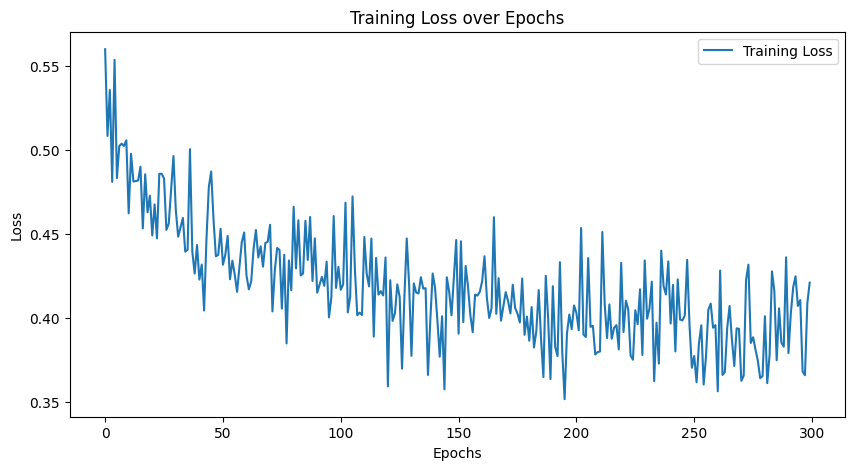

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()